# Исследование рынка заведений общественного питания Москвы

- Автор: Васильев Арсений
- Дата: 17.06.2025

### Цели и задачи проекта

**Цель:** проанализировать текущее состояние рынка общественного питания в Москве для выявления особенностей и закономерностей.

**Задачи:**
1. Провести предобработку данных.
2. Исследовать распределение заведений по категориям, районам и типу.
3. Проанализировать вместимость заведений.
4. Найти факторы, влияющие на рейтинг заведений.
5. Проанализировать ценообразование в зависимости от локации.
6. Сформулировать итоговые рекомендации.

### Описание данных

1. Датасет `rest_info.csv` (общая информация):
- `id` - уникальный идентификатор заведения.
- `name` - название заведения.
- `category` - тип заведения.
- `address` - полный физический адрес.
- `district` - административный округ Москвы.
- `hours` - график работы.
- `rating` - рейтинг заведения.
- `chain` - признак сетевого заведения (0 - несетевое, 1 - сетевое).
- `seats` - количество посадочных мест.
2. Датасет `rest_price.csv` (информация о ценах):
- `id` - уникальный идентификатор заведения.
- `price` - ценовая категория.
- `avg_bill` - средняя стоимость заказа.
- `middle_avg_bill` - средний чек.
- `middle_coffee_cup` - средняя стоимость чашки капучино.

### Содержимое проекта

1. [Загрузка данных и знакомство с ними](#1.-Загрузка-данных-и-знакомство-с-ними)
2. [Предобработка данных](#2.-Предобработка-данных)
3. [Исследовательский анализ данных](#3.-Исследовательский-анализ-данных)
4. [Итоговый вывод и рекомендации](#4.-Итоговый-вывод-и-рекомендации)

---

## 1. Загрузка данных и знакомство с ними

In [1]:
!pip install phik -U
from phik import phik_matrix

In [2]:
# необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# загружаем датасеты
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [4]:
# информация о rest_info
display(rest_info.head())
display(rest_info.info())

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


None

In [5]:
# информация о rest_price
display(rest_price.head())
display(rest_price.info())

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


None

---

### Промежуточный вывод

Датасет `rest_info` (8406 строк) содержит базовую информацию о заведениях.

Датасет `rest_price` (4058 строк) содержит финансовую информацию. Датафрейм с ценами в два раза меньше основного, что означает отсутствие данных о стоимости для значительной части заведений.

Оба датафрейма имеют общий уникальный столбец `id`, по которому будет произведено объединение таблиц.

**Пропуски**

В таблице `rest_info` отсутствуют данные о графике работы `hours` для 536 объектов, также мало данных о количестве посадочных мест `seats` заполнено чуть больше чем наполовину.

В таблице `rest_price` много пропусков в числовых столбцах чека, столбец стоимости чашки кофе `middle_coffee_cup` заполнен только для 535 объектов.

**Типы данных**

Типы данных адекватны. Рейтинг и места имеют тип float. Признак сетевого заведения `chain` имеет целочисленный тип (0 и 1), который можно использовать как логический.

### Подготовка единого датафрейма

Объединим оба датафрейма:

In [6]:
df = pd.merge(rest_info, rest_price, on='id', how='left')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


In [7]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len(temp)

8406

## 2. Предобработка данных

Подготовка данных к исследовательскому анализу.

**Корректность типов данных**

Проверим исходные типы данных в объединенном датафрейме.

In [8]:
# проверяем исходные типы данных
print("Исходные типы данных:")
print(df.dtypes)

Исходные типы данных:
id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object


Все типы данных адекватны, но признак сетевого заведения `chain` лучше перевести в логический тип данных `bool` для более удобной работы с ним.

In [9]:
# переводим признак сетевого заведения в bool
df['chain'] = df['chain'].astype(bool)

 Также снизим разрядность числовых столбцов с 64 битных до 32 битных float, это позволит уменьшить объем датафрейма без потери точности.

In [10]:
# понижаем разрядность числовых данных
cols = ['rating', 'middle_avg_bill', 'middle_coffee_cup', 'seats']

for col in cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

# проверяем
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   bool   
 8   seats              4795 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: bool(1), float32(4), object(8)
memory usage: 665.1+ KB


**Изучение и обработка пропусков**

Посчитаем количество и долю пропущенных значений в каждом столбце, выдвинем гипотезы об их появлении.

In [11]:
# выводим количество пропусков
display(df.isna().sum())

# выводим долю пропусков
display((df.isna().mean() * 100).round(2))

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

Гипотезы появления пропусков:
- `hours` (6.38%): информация о графике работы может отсутствовать из-за того, что владельцы заведений просто не заполнили это поле в карточке организации на яндекс картах. Пропуск MCAR, не зависит от других признаков.
- `seats` (42.96%): почти половина заведений на рынке работает в форматах, где вообще нет посадочных мест для клиентов (точки навынос, стрит-фуд, киоски или сервисы доставки). Также, возможно, не все владельцы могли предоставить данные о количестве мест в своих заведениях. Пропуск MNAR, может зависеть от фактического отсутствия мест.
- `price` (60.56%), `avg_bill` (54.6%), `middle_avg_bill` (62.54%): многие заведения не публикуют информацию о меню и ценах в карточке на яндекс картах. Разница в процентах между `avg_bill` и `middle_avg_bill` объясняется тем, что показатель `middle_avg_bill` извлекался только в том случае, если строка начиналась строго со слов «Средний счёт». Пропуски MAR, зависит от категории заведения.
- `middle_coffee_cup` (93.64%): это очень узкий показатель, который собирался по маркеру «Цена одной чашки капучино». Для большинства заведений (рестораны, пабы, пиццерии, столовые) этот параметр не является основным и не выводится в профиль организации. Пропуск MAR, зависит от типа заведения.

План обработки пропусков:
- Пропуски в текстовом столбце `hours` заполним заглушкой `неизвестно`, тк эти данные необходимы для выделения признака круглосуточной работы.
- Удалять строки с пропусками нельзя, тк мы потеряем от 42% до 93% всего датафрейма. Заполнять такое количество числовых пропусков расчетными значениями (например медианой или средним) также нельзя, тк это исказит распределение и испортит результаты дальнейшего анализа. Поэтому оставляем числовые пропуски как есть.

In [12]:
# заполняем пропуски в hours
df['hours'] = df['hours'].fillna('неизвестно')

**Проверка на явные и неявные дубликаты**

Сначала проверим данные на полные дубликаты.

In [13]:
# проверка на явные дубликаты
print(f"Количество полных явных дубликатов: {df.duplicated().sum()}")

Количество полных явных дубликатов: 0


Полных дубликатов не найдено (0).

Переходим к поиску неявных дубликатов. Искать дубликаты только по названию `name` нельзя тк на рынке много сетевых заведений с одинаковыми названиями, но разными адресами. Искать по адресу тоже может быть ошибкой тк например, в одном ТЦ может быть несколько разных заведений. Поэтому логичнее провести поиск неявных дубликатов по комбинации `name + address`, предварительно приведя всё к одному регистру (нижнему).

In [14]:
# приводим название и адрес к нижнему регистру, удаляем пробелы
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()

# находим дубликаты, keep покажет их
duplicate_rows = df[df.duplicated(subset=['name', 'address'], keep=False)]

# проверяем дубликаты перед удалением
display(duplicate_rows)

# считаем колво дубликатов для удаления
duplicates_count = df.duplicated(subset=['name', 'address']).sum()
print(f"\nКоличество неявных дубликатов для удаления (название+адрес): {duplicates_count}")

# удаляем найденные дубликаты
df = df.drop_duplicates(subset=['name', 'address']).reset_index(drop=True)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,False,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,False,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,False,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,True,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,False,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,True,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,True,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,неизвестно,4.1,False,276.0,NaN,NaN,NaN,NaN



Количество неявных дубликатов для удаления (название+адрес): 4


**Создание новых столбцов**

Создадим столбец `is_24_7` с обозначением того, что заведение работает круглосуточно.

In [15]:
# функция для проверки круглосуточности
def check_247(hours):
    hours = hours.lower() # приводим к нижнему регистру
    if 'ежедневно' in hours and 'круглосуточно' in hours:
        return True
    else:
        return False

# применим функцию
df['is_24_7'] = df['hours'].apply(check_247)

# выведем результат
print(df['is_24_7'].value_counts())

is_24_7
False    7672
True      730
Name: count, dtype: int64


In [16]:
# проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод

1. Столбец `chain` был переведен из числового типа данных в логический для удобства.
2. Пропуски в столбце `hours` заменены на `неизвестно`. Пропуски в количественных столбцах оставлены без изменений, чтобы не исказить результаты анализа.
3. Удалены неявные дубликаты (4) - записи с одинаковыми названиями по одному адресу. Полных дубликатов не найдено.
4. На основе столбца `hours` создан логический признак `is_24_7`, который принимает значение `True` если заведение работает круглосуточно.

**1. Общая информация о данных**
- Исходный размер данных: после объединения двух датасетов (`rest_info` и `rest_price`) по уникальному идентификатору `id`, размер единого датафрейма составил 8422 строки и 13 столбцов.
- Размер после преобразований: в результате очистки данных и удаления дубликатов финальный размер составил 8418 строк и 14 столбцов.
- Описание набора данных: датасет содержит информацию о заведениях общественного питания Москвы за лето 22 года.

**2. Типы данных**
- Выполненные преобразования: для оптимизации памяти разрядность числовых столбцов `rating`, `middle_avg_bill`, `middle_coffee_cup` и `seats` была снижена с 64-битных до 32-битных значений.
- Столбец `chain` (признак сетевого заведения) был переведён из числового формата в более корректный логический тип данных `bool`.
- Корректность: на текущем этапе все столбцы имеют логичные и оптимизированные типы данных, подходящие для анализа.

**3. Пропущенные значения**
- Обнаруженные пропуски: пропущенные значения присутствовали в столбцах `hours` (часы работы), `seats` (посадочные места), `price` (ценовая категория) и в столбцах с финансовыми значениями (`middle_avg_bill` и `middle_coffee_cup`).
- Методы обработки: текстовые пропуски в столбце `hours` заполнены строковым значением `неизвестно`.
- Пропуски в количественных столбцах (`seats`, `middle_avg_bill`, `middle_coffee_cup`) и категориальном столбце `price` были оставлены без изменений, чтобы не исказить результаты будущего анализа.

**4. Дубликаты**
- Явные дубликаты: полных идентичных строк дубликатов не обнаружено.
- Неявные дубликаты: проведён поиск неявных дубликатов по комбинации `name` + `address` после нормализации. Было найдено 4 дубликата.
- Метод обработки: все 4 неявных дубликата были удалены, индексы строк обновлены.

**5. Создание дополнительных признаков**
- На основе информации о режиме работы из столбца `hours` был сформирован новый логический признак `is_24_7`, который принимает значение `True`, если заведение работает ежедневно и круглосуточно и `False` - во всех остальных случаях.

**6. Итоговое состояние данных**
- Итоговое количество строк: 8418.
- Готовность к анализу: данные очищены от неявных повторов, оптимизированы по типам и объёму памяти, дополнены необходимыми признаками. Датасет готов к проведению исследовательского анализа данных.

## 3. Исследовательский анализ данных

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.
- Сгруппируем данные по категориям и посчитаем количество. Лучше всего подойдет столбчатая диаграмма, тк названия могут быть длинными.

,category,count,percent
3,кафе,2376,0.282790
6,ресторан,2042,0.243037
4,кофейня,1413,0.168174
0,"бар,паб",764,0.090931
5,пиццерия,633,0.075339
2,быстрое питание,603,0.071769
7,столовая,315,0.037491
1,булочная,256,0.030469


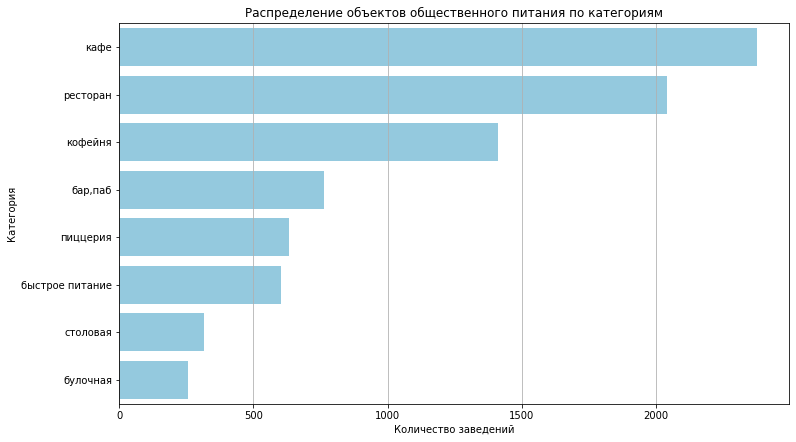

In [17]:
# группируем, считаем количество и сортируем по убыванию
category_count = df.groupby('category')['id'].count().reset_index()
category_count = category_count.rename(columns={'id': 'count'})
category_count = category_count.sort_values(by='count', ascending=False)

# добавляем вывод относительных значений
category_count['percent'] = (category_count['count'] / category_count['count'].sum())

# проверим результат
display(category_count)

# строим график
plt.figure(figsize=(12, 7))

sns.barplot(data=category_count, x='count', y='category', color='skyblue')

plt.title('Распределение объектов общественного питания по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')

plt.grid(axis='x') 

plt.show()

Лидирующей категорией являются кафе (2376 объектов), они занимают самую большую долю рынка (28.3%). Также на рынке широко представлены рестораны (2042 объекта, 24.3%) и кофейни (1413 объектов, 16.8%). Эти три категории формируют основу общепита Москвы и занимают почти 70% всего рынка.
Бары и пабы составляют 9.1% всех заведений, пиццерии - 7.5%, заведения быстрого питания - 7.2%.
Меньше всего в Москве представлены столовые (3.7%) и булочные - всего 256 заведений  (3%).
В Москве преобладают форматы повседневного спроса (кафе, рестораны и кофейни).

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.
- Изучим распределение по всем округам
- Отфильтруем данные только для ЦАО и посмотрим категории

,district,count,percent
5,Центральный административный округ,2242,0.266841
2,Северный административный округ,898,0.106879
8,Южный административный округ,892,0.106165
3,Северо-Восточный административный округ,890,0.105927
1,Западный административный округ,850,0.101166
0,Восточный административный округ,798,0.094977
6,Юго-Восточный административный округ,714,0.084980
7,Юго-Западный административный округ,709,0.084385
4,Северо-Западный административный округ,409,0.048679


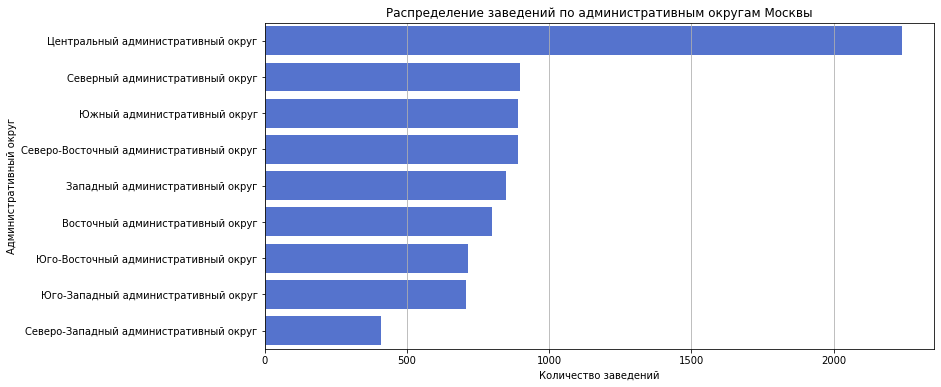

In [18]:
# считаем колво заведений по округам
district_count = df.groupby('district')['id'].count().reset_index()
district_count = district_count.rename(columns={'id': 'count'})
district_count = district_count.sort_values(by='count', ascending=False)

# добавляем доли
district_count['percent'] = (district_count['count'] / district_count['count'].sum())

# проверим результат
display(district_count)

# строим график
plt.figure(figsize=(12, 6))
sns.barplot(data=district_count, x='count', y='district', color='royalblue')

plt.title('Распределение заведений по административным округам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Административный округ')
plt.grid(axis='x')

plt.show()

,category,count,percent
6,ресторан,670,0.298840
3,кафе,464,0.206958
4,кофейня,428,0.190901
0,"бар,паб",364,0.162355
5,пиццерия,113,0.050401
2,быстрое питание,87,0.038805
7,столовая,66,0.029438
1,булочная,50,0.022302


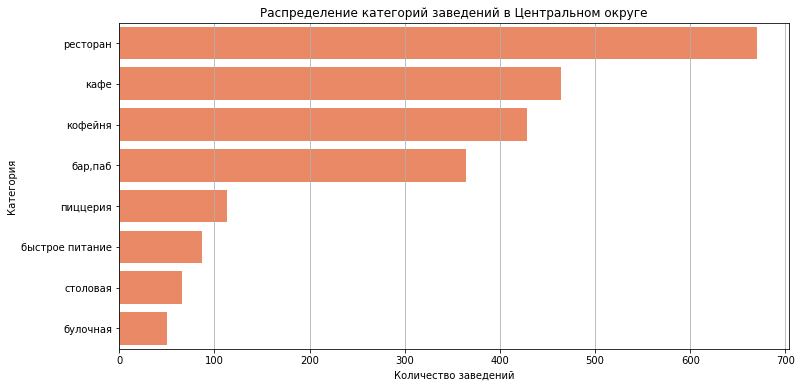

In [19]:
# оставляем только ЦАО
central_df = df[df['district'] == 'Центральный административный округ']

# считаем колво заведений по категориям в ЦАО
central_category_count = central_df.groupby('category')['id'].count().reset_index()
central_category_count = central_category_count.rename(columns={'id': 'count'})
central_category_count = central_category_count.sort_values(by='count', ascending=False)

# добавляем доли
central_category_count['percent'] = (central_category_count['count'] / central_category_count['count'].sum())

# проверим результат
display(central_category_count)

# строим график
plt.figure(figsize=(12, 6))
sns.barplot(data=central_category_count, x='count', y='category', color='coral')

plt.title('Распределение категорий заведений в Центральном округе')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

1. **По административным округам:** лидером по количеству объектов общественного питания является Центральный административный округ (ЦАО) - 2242 заведения, что составляет 26.7% от всего города. Далее с почти одинаковым количеством заведений расположены Северный (898 заведений, 10.7%), Южный (892 заведения, 10.6%) и Северо-Восточный (890 заведений, 10.6%) округа. Меньше всего заведений расположено в Северо-Западном административном округе (409 заведений, или 4.9%). Такое распределение наглядно отражает концентрацию активности именно в центре города.

2. **В Центральном административном округе (ЦАО):** чаще всего встречаются рестораны (670 объектов, 29.9%), на втором месте - кафе (464 объекта, 20.7%), на третьем месте с небольшим разрывом - кофейни (428 объектов, 19.1%). Форматы быстрого и бюджетного питания (быстрое питание - 3.9%, столовые - 2.9% и булочные - 2.2%) представлены в ЦАО минимально. Центральный округ - главная зона для отдыха и деловых встреч, где люди отдают предпочтение полноценному обслуживанию и комфорту. При этом структура центра отличается от остального города, по всей Москве на первом месте по популярности идут кафе, а в центре лидируют именно рестораны.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.
- Посчитаем общее соотношение сетевиков и одиночных заведений. Подойдет вертикальная столбчатая диаграмма
- Найдем долю сетевых заведений в каждой категории

,chain,count,percent,chain_name
0,False,5199,0.618781,Несетевые
1,True,3203,0.381219,Сетевые


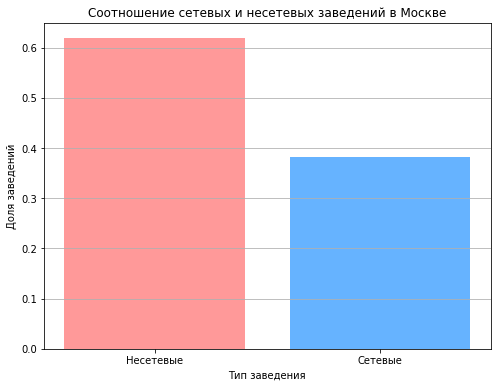

In [20]:
# считаем количество сетевых и несетевых заведений
chain_count = df.groupby('chain')['id'].count().reset_index()
chain_count = chain_count.rename(columns={'id': 'count'})

# добавляем доли
chain_count['percent'] = (chain_count['count'] / chain_count['count'].sum())

# заменим true/false на текстовые названия
chain_count['chain_name'] = chain_count['chain'].replace({False: 'Несетевые', True: 'Сетевые'})

# проверим результат
display(chain_count)

# строим столбчатую диаграмму по относительным значениям (процентам)
plt.figure(figsize=(8, 6))

plt.bar(chain_count['chain_name'], chain_count['percent'], color=['#ff9999', '#66b3ff'])

plt.title('Соотношение сетевых и несетевых заведений в Москве')
plt.xlabel('Тип заведения')
plt.ylabel('Доля заведений')

plt.grid(axis='y')

plt.show()

,category,Общее количество,Из них сетевых,% сетевых
0,"бар,паб",764,168,21.989529
7,столовая,315,88,27.936508
3,кафе,2376,779,32.786195
6,ресторан,2042,729,35.700294
2,быстрое питание,603,232,38.474295
4,кофейня,1413,720,50.955414
5,пиццерия,633,330,52.132701
1,булочная,256,157,61.328125


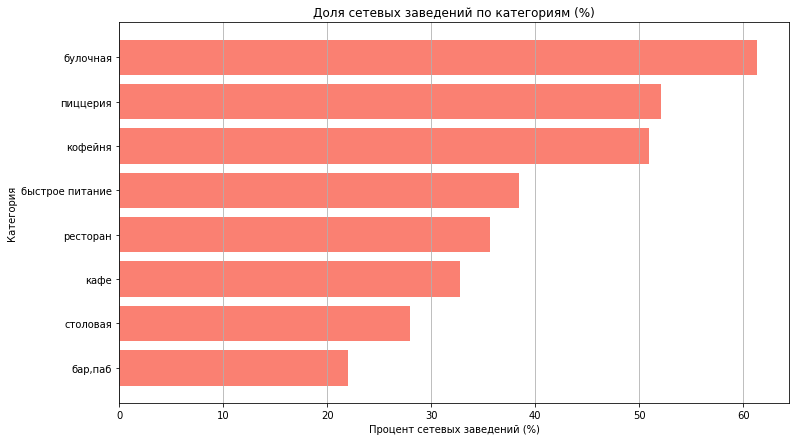

In [21]:
# группируем по категории и считаем общее колво заведений и колво сетевых
chain_cat = df.groupby('category')['chain'].agg(['count', 'sum']).reset_index()

# считаем процент сетевых заведений
chain_cat['percent'] = (chain_cat['sum'] / chain_cat['count']) * 100

# сортируем по убыванию процента
chain_cat = chain_cat.sort_values(by='percent', ascending=True)

# переименуем столбцы
chain_cat = chain_cat.rename(columns={'count': 'Общее количество', 'sum': 'Из них сетевых', 'percent': '% сетевых'})

# проверим результат
display(chain_cat)

# строим график
plt.figure(figsize=(12, 7))

plt.barh(chain_cat['category'], chain_cat['% сетевых'], color='salmon')

plt.title('Доля сетевых заведений по категориям (%)')
plt.xlabel('Процент сетевых заведений (%)')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

1. **Общее соотношение:** в Москве большинство заведений являются несетевыми (5199 объектов, 62%). Заведений в сетевом формате - 3203 (38%). На рынке много конкуренции, много уникальных, единичных проектов.


2. **Сетевые форматы по категориям:** чаще всего сетевыми являются булочные (61% из них - это сети) и пиццерии (52%). Реже всего сетевой формат встречается среди баров и пабов (всего 22%). Сделать небольшие сетевые заведения по типу булочных гораздо проще и выгоднее для масштабирования. Пиццерии пользуются популярностью в доставках, отсюда большое количество пунктов.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.

- Построим диаграмму размаха для поиска анамалий
- Посчитаем медиану для каждой категории и выведем на график

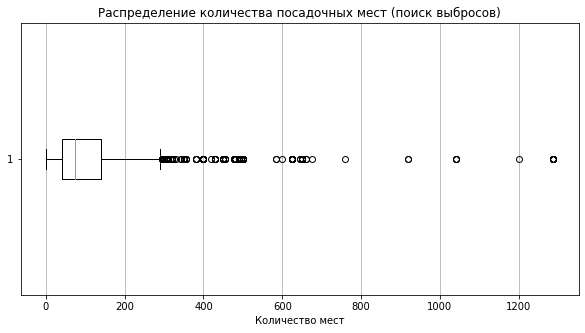

Статистика по посадочным местам:
count    4792.000000
mean      108.361435
std       122.841225
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64


In [22]:
# отбросим пропуски в seats
seats_data = df['seats'].dropna()

# строим ящик с усами
plt.figure(figsize=(10, 5))
plt.boxplot(seats_data, vert=False)

plt.title('Распределение количества посадочных мест (поиск выбросов)')
plt.xlabel('Количество мест')
plt.grid(axis='x')

plt.show()

# числовое описание столбца
print("Статистика по посадочным местам:")
print(seats_data.describe())

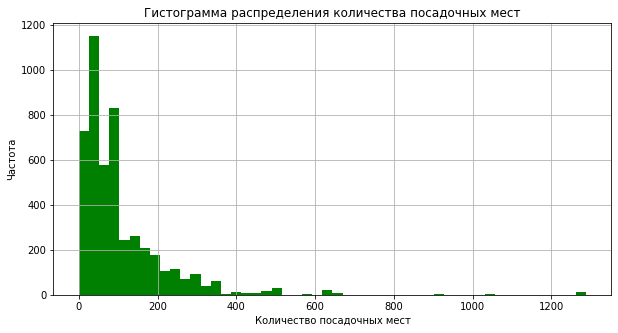

In [23]:
# отбросим пропуски в seats
seats_data = df['seats'].dropna()

# строим гистограмму распределения мест
plt.figure(figsize=(10, 5))
plt.hist(seats_data, bins=50, color='green')

plt.title('Гистограмма распределения количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.grid()

plt.show()

,category,Медианное количество мест
1,булочная,50.0
5,пиццерия,55.0
3,кафе,60.0
2,быстрое питание,65.0
7,столовая,75.5
4,кофейня,80.0
0,"бар,паб",82.0
6,ресторан,86.0


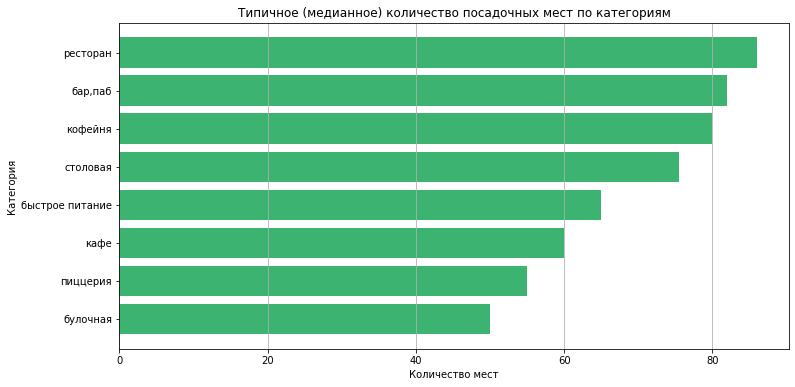

In [24]:
# группируем по категории и считаем медиану
typical_seats = df.groupby('category')['seats'].median().reset_index()

# сортируем по убыванию
typical_seats = typical_seats.sort_values(by='seats', ascending=True)
typical_seats = typical_seats.rename(columns={'seats': 'Медианное количество мест'})

# проверим результат
display(typical_seats)

# строим горизонтальный график
plt.figure(figsize=(12, 6))

plt.barh(typical_seats['category'], typical_seats['Медианное количество мест'], color='mediumseagreen')

plt.title('Типичное (медианное) количество посадочных мест по категориям')
plt.xlabel('Количество мест')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

1. **Аномалии и выбросы:** анализ распределения посадочных мест (boxplot и describe) показывает наличие сильного разброса и множества выбросов. Основная масса заведений (75% выборки) имеет вместимость до 140 посадочных мест, а медианное значение по всему рынку составляет 75 мест. Среднее арифметическое (108 мест) сильно смещено из-за длинного хвоста аномальных значений, достигающего максимума в 1288 мест. Эти значения отражают специфику рынка: наличие крупных залов, масштабных столовых при предприятиях, фуд-кортов или концертных площадок.


2. **Типичное количество мест:** из-за сильного искажения средних значений выбросами, оценку типичной вместимости внутри каждой категории проводили по медиане. Самым вместительным форматом оказались рестораны (медиана 86 мест). На втором месте бары и пабы (82 места). Наименьшее количество мест характерно для форматов быстрого питания и точек навынос: булочные (50) и пиццерии (55).

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

- Изучим рейтинг заведений, визулазириуем с помощью столбчатой диаграммы

count    8402.000000
mean        4.230016
std         0.470318
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124284,0.566003,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277282,0.372251,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290401,0.413142,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


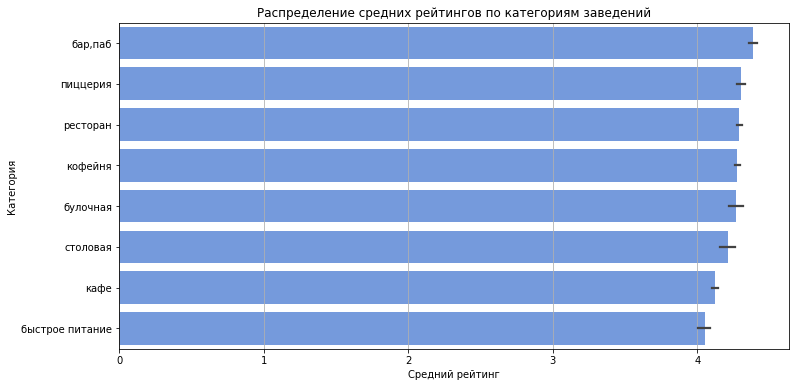

In [25]:
# смотрим сводную статистику
display(df['rating'].describe())

# смотрим вариацию рейтингов по категориям
display(df.groupby('category')['rating'].describe())

# считаем средний рейтинг и сортируем по убыванию
avg_rating = df.groupby('category')['rating'].mean().reset_index()
avg_rating = avg_rating.sort_values(by='rating', ascending=False)

# строим график
plt.figure(figsize=(12, 6))

# добавлен порядок (order)
sns.barplot(data=df, x='rating', y='category', color='cornflowerblue', order=avg_rating['category'])

plt.title('Распределение средних рейтингов по категориям заведений')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')

plt.grid(axis='x')

plt.show()

Сводная статистика показывает, что оценки пользователей варьируются от 1 до 5 баллов, единичные низкие оценки встречаются во всех категориях.

Средние рейтинги распределены очень плотно в узком диапазоне от 4.05 до 4.39 баллов, что говорит о высокой конкуренции на рынке общепита Москвы.

Лидирующие позиции по среднему рейтингу занимают форматы, где важна атмосфера и сервис: бары и пабы (4.39), пиццерии (4.3) и рестораны (4.29). В то же время массовые форматы с большим количеством людей - кафе (4.12) и быстрое питание (4.05) - оцениваются строже. Скорее всего в фастфуде клиенты чаще сталкиваются с очередями или частыми ошибками, что слегка снижает итоговый балл.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

- Построим матрицу корреляции и визуализируем наиболее сильную связь рейтинга

interval columns not set, guessing: ['rating', 'seats']


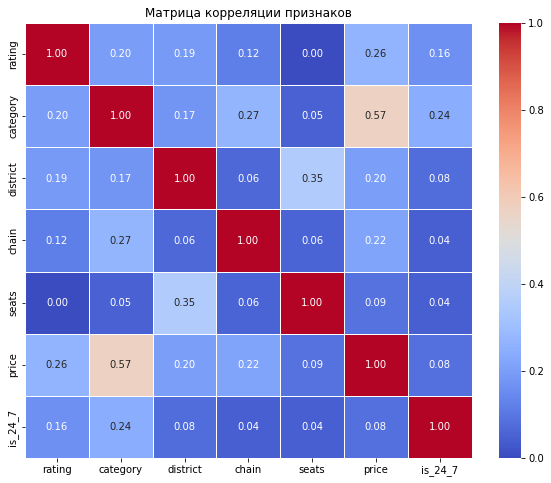

In [26]:
# отбираем столбцы
cols_to_check = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']

# считаем матрицу корреляций
phik_matrix = df[cols_to_check].phik_matrix()

# строим тепловую карту
plt.figure(figsize=(10, 8))

sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

plt.title('Матрица корреляции признаков')

plt.show()

,price,rating
0,высокие,4.436611
1,выше среднего,4.386347
3,средние,4.297874
2,низкие,4.173077


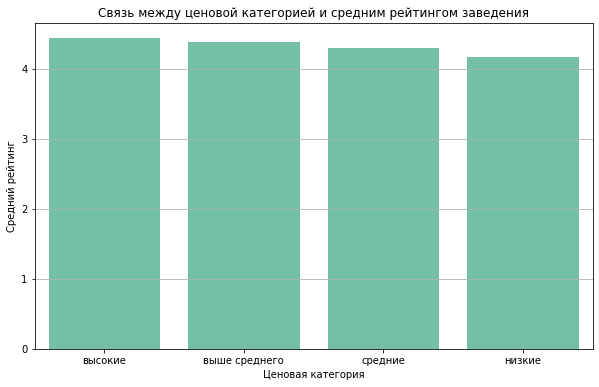

In [27]:
# группируем по ценовой категории и считаем средний рейтинг
price_rating = df.groupby('price')['rating'].mean().reset_index()

# сортируем по убыванию рейтинга
price_rating = price_rating.sort_values(by='rating', ascending=False)

# выводим таблицу
display(price_rating)

# строим столбчатую диаграмму средних рейтингов
plt.figure(figsize=(10, 6))

sns.barplot(data=price_rating, x='price', y='rating', color='mediumaquamarine')

plt.title('Связь между ценовой категорией и средним рейтингом заведения')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')

# добавляем сетку по оси Y для удобства сравнения
plt.grid(axis='y') 

plt.show()

1. Анализ матрицы корреляций показал, что из всех доступных признаков рейтинг заведения сильнее всего связан с ценовой категорией (коэффициент 0.22, слабая полжительная связь). Остальные факторы, такие как вместимость, район или сетевой статус, практически не влияют на оценку гостей.


2. Диаграмма размаха объясняет эту связь и показывает распределение рейтингов внутри каждой ценовой категории. 
В дорогих сегментах (высокие и выше среднего) медианный рейтинг самый высокий (около 4.5 баллов). У категорий "выше среднего" и "средние" самый минимальный разброс. Основная масса оценок здесь не опускается ниже 4.0-4.2. Это значит, что высокий чек  гарантирует гостям более стабильный уровень качества, плохих заведений в этом сегменте практически нет. В массовых сегментах (средние и ниже среднего) медианный рейтинг ниже (около 4.3-4.4), главное отличие - разброс оценок. Качество сервиса в массмаркете нестабильно, есть как заведения с низким рейтингом, так и места с идеальной оценкой 5.0 (верхние точки выбросы на графике). Также в категории "средние" можно заметить большое количество выбросов с рейтингом 3.0-4.0.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.
- Отфильтруем данные и определим топ15 заведений по количеству точек. Подойдет столбчатая диаграмма

,Название сети,Категория,Количество точек,Средний рейтинг
1126,шоколадница,кофейня,119,4.178151
496,домино'с пицца,пиццерия,76,4.169737
489,додо пицца,пиццерия,74,4.286487
205,one price coffee,кофейня,71,4.064789
1142,яндекс лавка,ресторан,69,3.872464
72,cofix,кофейня,65,4.075385
241,prime,ресторан,49,4.114285
617,кофепорт,кофейня,42,4.147619
632,кулинарная лавка братьев караваевых,кафе,39,4.394872
963,теремок,ресторан,36,4.105556


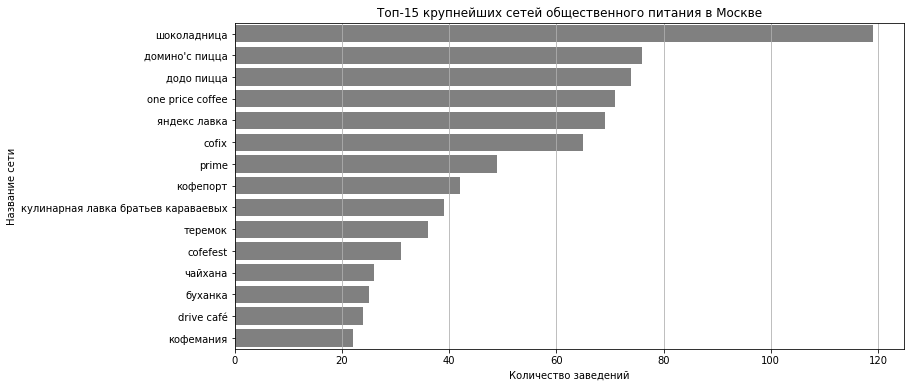

In [28]:
# отфильтруем только сетевые заведения
chain_df = df[df['chain'] == True]

# группируем по названию и категории
# считаем количество и средний рейтинг
top_chains = chain_df.groupby(['name', 'category']).agg(
    count=('id', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# переименуем столбцы
top_chains = top_chains.rename(columns={
    'count': 'Количество точек', 
    'avg_rating': 'Средний рейтинг',
    'name': 'Название сети',
    'category': 'Категория'
})

# сортируем по количеству точек и берем топ15
top_15_chains = top_chains.sort_values(by='Количество точек', ascending=False).head(15)

# проверяем результат
display(top_15_chains)

# строим график по количеству точек
plt.figure(figsize=(12, 6))

sns.barplot(data=top_15_chains, x='Количество точек', y='Название сети', color='grey')

plt.title('Топ-15 крупнейших сетей общественного питания в Москве')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')

plt.grid(axis='x')

plt.show()

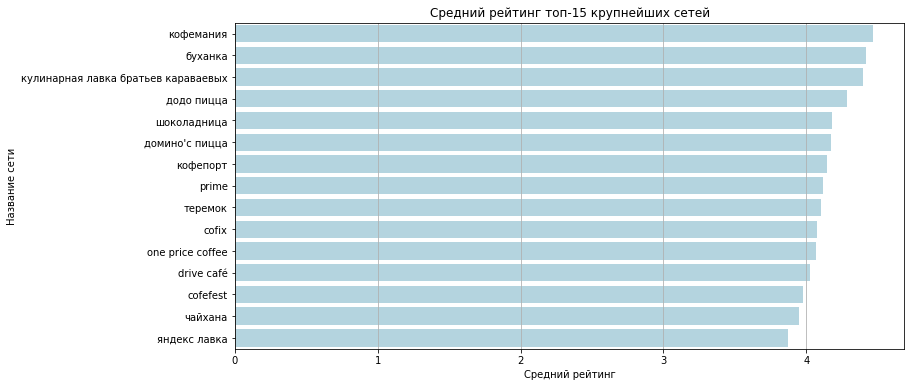

In [29]:
# строим диаграмму по среднему рейтингу
top_15_rating = top_15_chains.sort_values(by='Средний рейтинг', ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(data=top_15_rating, x='Средний рейтинг', y='Название сети', color='lightblue')

plt.title('Средний рейтинг топ-15 крупнейших сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')

plt.grid(axis='x')

plt.show()

Анализ топ15 крупнейших сетей показал, что на рынке лидируют кофейни (Шоколадница, One Price Coffee, Cofix, Кофепорт, Cofefest, Кофемания) и пиццерии (Доминос, Додо). Лидером по количеству точек является кофейня Шоколадница (119 заведений). Большое количество кофеен и пиццерий в топе подтверждает успешность простых продуктов, ориентированных на массового потребителя и формат навынос.

Анализ средних рейтингов этих заведений показывает, что масштаб бизнеса не всегда гарантирует высокую оценку. Самые высокие баллы среди топ-15 получают сети «Кофемания» (4.46), Буханка (4.42) и Кулинарная лавка братьев караваевых (4.39). В конце топа по рейтингу - Яндекс лавка со средним баллом 3.87. Массовые форматы с быстрой выдачей и доставкой оцениваются строже, а сети с упором на комфорт и премиальный сервис (например Кофемания) держат более высокую планку.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.

- Проанализируем средний чек по округам и построим диаграмму размаха

count     3149.000000
mean       958.053650
std       1009.734436
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

,district,Медианный чек,Средний чек
1,Западный административный округ,1000.0,1053.225464
5,Центральный административный округ,1000.0,1191.057495
4,Северо-Западный административный округ,700.0,822.222900
2,Северный административный округ,650.0,927.959656
7,Юго-Западный административный округ,600.0,792.561707
0,Восточный административный округ,575.0,820.626953
3,Северо-Восточный административный округ,500.0,716.611267
8,Южный административный округ,500.0,834.398071
6,Юго-Восточный административный округ,450.0,654.097961


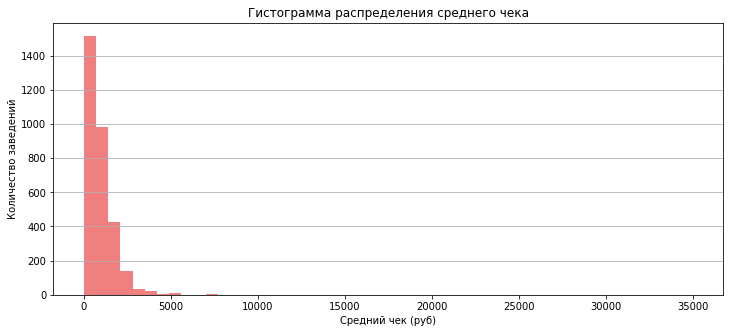

In [30]:
# отбрасываем пропуски в столбце со средним чеком
price_df = df.dropna(subset=['middle_avg_bill'])

# выводим общую статистику
display(price_df['middle_avg_bill'].describe())

# считаем и медиану, и среднее значение чека по округам
district_stats = price_df.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).reset_index()
district_stats = district_stats.rename(columns={'median': 'Медианный чек', 'mean': 'Средний чек'})
district_stats = district_stats.sort_values(by='Медианный чек', ascending=False)

display(district_stats)

# строим гистограмму распределения среднего чека
plt.figure(figsize=(12, 5))

plt.hist(price_df['middle_avg_bill'], bins=50, color='lightcoral')

plt.title('Гистограмма распределения среднего чека')
plt.xlabel('Средний чек (руб)')
plt.ylabel('Количество заведений')

plt.grid(axis='y')

plt.show()

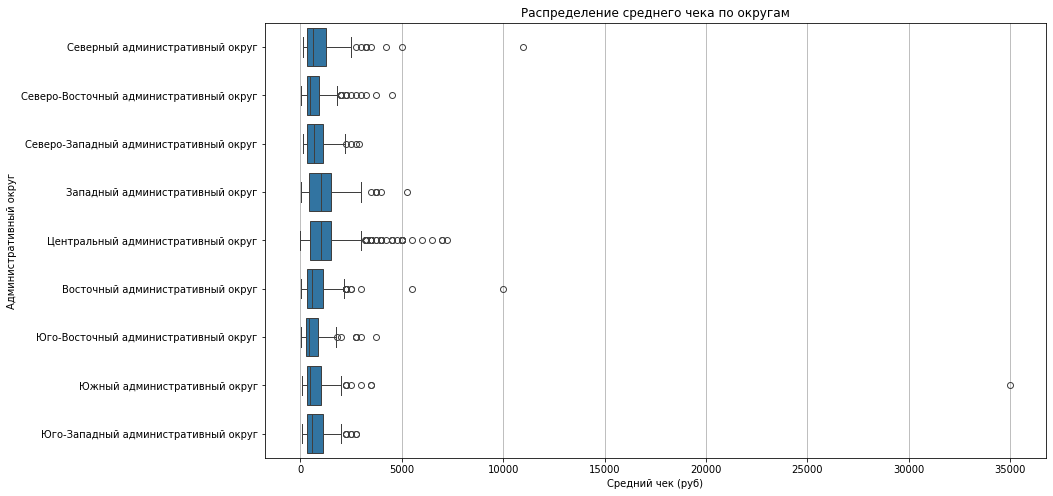

In [31]:
# строим диаграмму размаха
plt.figure(figsize=(14, 8))

sns.boxplot(data=price_df, x='middle_avg_bill', y='district')

plt.title('Распределение среднего чека по округам')
plt.xlabel('Средний чек (руб)')
plt.ylabel('Административный округ')

plt.grid(axis='x')

plt.show()

1. Самый высокий медианный чек (1000 руб) в Центральном (ЦАО) и Западном (ЗАО) округах. При этом график наглядно показывает, что именно в ЦАО наблюдается самый широкий диапазон цен и скопление дорогих заведений.


2. По мере удаления от центра цены плавно снижаются. Самые бюджетные заведения сконцентрированы в Юго-Восточном (медиана 450 руб), Южном и Северо-Восточном округах (500 руб). График показывает, что в этих районах рынок представлен массмаркетом с малым разбросом цен.

---

### Промежуточный вывод

**Форматы и локации:** рынок ориентирован на повседневный спрос - много кафе, ресторанов и кофеен. Главной точкой является Центральный административный округ (ЦАО), где расположена четверть всех заведений.

**Сетевой признак:** более 60% рынка занимают уникальные несетевые проекты. В нишах с простыми продуктами и быстрым обслуживанием (пекарни, пиццерии, фастфуд) сетевой формат показывает большую эффективность. Крупнейшие заведения (топ15) делятся на две части: одни фокусируются на большой проходимости в ЦАО (например Шоколадница), другие стремятся к равномерному покрытию районов (Додо, Яндекс лавка).

**Вместимость:** типичное количество посадочных мест сильно зависит от формата. Рестораны и пабы обычно делают комфортную посадку (80+ мест), а массмаркет рассчитан на быструю работу (50 мест).

**Рейтинги:** оценки заведений распределены очень плотно (в среднем 4.0-4.4 балла), что говорит о высоких стандартах. Наблюдается небольшая положительная корреляция между средним чеком и ценовой категорией.

---
## 4. Итоговый вывод и рекомендации

**1. Общий обзор проделанной работы**

В рамках проекта было проведено исследование рынка общественного питания Москвы на основе данных о более чем 8000 заведений.
- Была выполнена предобработка данных (удалены дубликаты, обработаны пропуски и скорректированы типы данных), а затем детальный исследовательский анализ.
- Были изучены популярные форматы общепита, их географическое распределение, соотношение сетевых и несетевых заведений, вместимость и факторы, влияющие на ценообразование и рейтинг.

**2. Главные выводы исследования**

- Рынок ориентирован на повседневный спрос. Абсолютные лидеры по количеству точек - кафе, рестораны и кофейни.

- Центр столицы (ЦАО) является главной зоной. Здесь больше всего заведений, самый высокий медианный чек (1000 руб) и наибольший выбор дорогих мест. По мере удаления от центра к окраинам (Юго-Восточный, Северо-Восточный округа) цены заметно падают (медиана 450-500 руб).

- Более 60% рынка состоит из уникальных (несетевых) заведений. Но в нишах с простым продуктом сети доминируют: например 61% всех булочных и 52% пиццерий это сетевые проекты (Шоколадница, Додо). Сетевики делятся на два типа: одни делают упор на центральные точки для охвата трафика, другие расположены в разных регионах для доставки.

- Ресторанам и пабам требуются большие залы (в среднем 80-86 мест), форматам быстрого питания (кофейням и пиццериям) достаточно компактных помещений (около 50 мест).

- Из-за высокой конкуренции плохие заведения на рынке не выживают (средние оценки начинаются от 4 баллов). При этом дорогие заведения стабильно держат высокую планку. В бюджетном сегменте (с чеком до 1000 руб) качество обслуживания сильно скачет.

**3. Рекомендации для заказчика**

На основе выявленных закономерностей можно дать следующие рекомендации по открытию новых заведений:

- Если планируется масштабирование и создание крупной сети, лучше выбирать форматы с понятным и простым продуктом (кофейня, пекарня, пиццерия). Для открытия уникального одиночного проекта лучше выбрать формат классического кафе или ресторана.

- Заведения с высоким средним чеком имеет смысл открывать в ЦАО или ЗАО, где сосредоточена платежеспособная аудитория. В спальных районах (особенно на востоке и юге Москвы) лучше запускать бюджетные форматы и обязательным упором на доставку.

- Не стоит переплачивать за аренду огромных помещений, если это не классический ресторан. Для успешной пекарни или кафе быстрого питания оптимальной будет вместимость около 40-50 мест.